# Function 3 — 3D Drug Discovery

**Objective:** minimise adverse reactions, framed as maximisation of negative
side effects
**Surrogate:** GP with Matérn 5/2 kernel
**Acquisition:** Expected Improvement (EI), ξ = 0.05

---

Three compound concentrations in [0, 1], returning a score for adverse
reactions. One query per week, five rounds completed.

Because the output is *already* the negative of the side effect measure,
maximising Y directly minimises the reactions. No sign flip is applied
anywhere — an easy thing to get backwards, and getting it backwards would send
the search in exactly the wrong direction.

With three inputs the surface cannot be drawn directly, so the visualisation
below shows all C(3,2) = 3 pairwise slices, fixing the remaining axis at the
next sample's value.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.model_selection import LeaveOneOut
from scipy.stats import norm
from itertools import combinations

import warnings
warnings.filterwarnings("ignore")

## 1. Data

Loaded from `../data/function_3.csv` rather than pasted inline.

This matters more than it sounds. In the original script the `X` array had
grown to 21 rows while `Y` had 20 values — a pending round-6 query had been
added before its result came back. `model.fit(X, Y)` raises a shape-mismatch
error in that state, and the cause is not obvious from the traceback.

Keeping observations in one file, with a `week` column, makes that class of
mistake impossible: a row without a result simply does not exist yet.

In [2]:
# -----------------------------------------------------------------
#  DATA
# -----------------------------------------------------------------
df = pd.read_csv("../data/function_3.csv", float_precision="round_trip")

X    = df[["x1", "x2", "x3"]].values     # compound concentrations
Y    = df["y"].values                    # negative side effects
week = df["week"].values                 # 0 = supplied, 1-5 = our submissions

print("Data shapes:")
print(f"  X : {X.shape}")
print(f"  Y : {Y.shape}")
print(f"\nY range : [{Y.min():.6f},  {Y.max():.6f}]")
print("Note: Y = negative side effects — maximising Y minimises reactions")

df.tail()

Data shapes:
  X : (20, 3)
  Y : (20,)

Y range : [-0.478170,  -0.034835]
Note: Y = negative side effects — maximising Y minimises reactions


,week,x1,x2,x3,y
15,1,0.550000,0.650000,0.360000,-0.037156
16,2,0.500000,0.999999,0.999999,-0.478170
17,3,1.000000,0.000000,0.684211,-0.176918
18,4,0.000000,1.000000,0.684211,-0.158070
19,5,0.448276,0.206897,0.551724,-0.054088


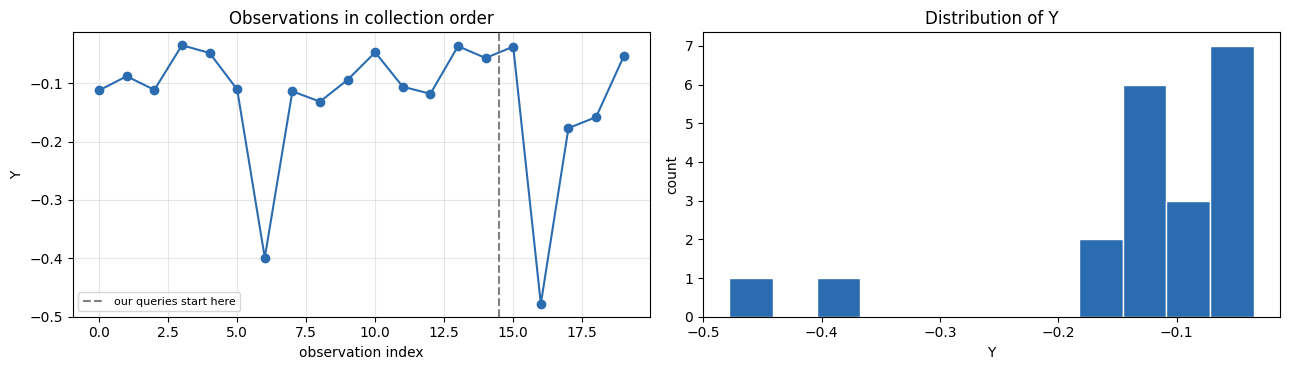

In [3]:
# Left  : scores in collection order, our five queries to the right of the line
# Right : how the scores are distributed
#
# These are what tell us whether the target needs reshaping before modelling.

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

axes[0].plot(Y, "o-", color="#2b6cb0")
axes[0].axvline(np.sum(week == 0) - 0.5, color="grey", linestyle="--",
                label="our queries start here")
axes[0].set_xlabel("observation index")
axes[0].set_ylabel("Y")
axes[0].set_title("Observations in collection order")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].hist(Y, bins=12, color="#2b6cb0", edgecolor="white")
axes[1].set_xlabel("Y")
axes[1].set_ylabel("count")
axes[1].set_title("Distribution of Y")

plt.tight_layout()
plt.show()

## 2. Transforming the target

**No transform is applied to Function 3.**

The outputs run from −0.399 to −0.035 — a tight, consistent range with no
orders-of-magnitude spread. There is nothing to compress.

Stating this explicitly matters. Functions 1, 4, 5 and 7 all needed transforms,
and it would be easy to apply one here out of habit. Every transform changes
the shape of the surface the GP fits, and therefore which regions the
acquisition function favours, so applying one without cause does harm rather
than good.

In [4]:
# No transform: the target is already on a compact, well-behaved scale.
# Y_model is defined anyway so the notebook reads the same as the others.

Y_model = Y.astype(float)

print(f"No transform applied.")
print(f"Range: {Y_model.min():.6f} to {Y_model.max():.6f}")

No transform applied.
Range: -0.478170 to -0.034835


## 3. Kernel

`ConstantKernel × Matérn(ν=5/2) + WhiteKernel`

| Component | Setting | Role |
|---|---|---|
| `ConstantKernel` | bounds (1e-3, 1e3) | Learns overall signal amplitude. |
| `Matérn(ν=2.5)` | — | Smooth but flexible. Appropriate for a drug response surface that is continuous but may have ridges where one compound dominates. |
| `length_scale` | 0.3, bounds (0.01, 2.0) | Moderate reach across the [0,1]³ compound space, which is expected to be moderately smooth. |
| `WhiteKernel` | 0.01, bounds (1e-6, 1.0) | Explicit noise term — biological assays are noisy. Lower than Function 2's 0.1 because these values sit on a much tighter scale. |

In [5]:
# -----------------------------------------------------------------
#  KERNEL
# -----------------------------------------------------------------
kernel = (
    ConstantKernel(
        constant_value=1.0,
        constant_value_bounds=(1e-3, 1e3),      # overall signal amplitude
    )
    * Matern(
        nu=2.5,                                 # smooth, but allows ridges
        length_scale=0.3,
        length_scale_bounds=(0.01, 2.0),
    )
    + WhiteKernel(
        noise_level=0.01,                       # biological assay noise
        noise_level_bounds=(1e-6, 1.0),
    )
)

# -----------------------------------------------------------------
#  GP MODEL
# -----------------------------------------------------------------
xi = 0.05      # EI exploration parameter — raise to 0.10 to explore more

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=25,
    normalize_y=True,
    random_state=42,
)
model.fit(X, Y_model)

print(f"Optimised kernel:\n  {model.kernel_}")

fitted_ls = model.kernel_.k1.k2.length_scale
if fitted_ls <= 0.011:
    print(f"\n  WARNING: length_scale {fitted_ls:.4f} is at its lower bound.")
    print("  The model wants sharper variation than the kernel allows.")

Optimised kernel:
  1.22**2 * Matern(length_scale=0.367, nu=2.5) + WhiteKernel(noise_level=1e-06)


## 4. Does the model actually work?

Fitting a GP always produces a smooth, plausible-looking surface. That is not
evidence it has learned anything.

Leave-one-out cross-validation tests it directly: hide one observation, refit
on the rest, predict the hidden point, repeat for all 20.

Two measures are reported.

**RMSE** is the average size of the prediction error, in the units of this
function's target. It is an absolute measure — it says how wrong the model is,
not merely how it compares with an alternative — which makes it the more
interpretable of the two and the better choice when comparing different kinds
of model.

**R²** expresses the same error as a proportion of the variance: 1.0 is
perfect, 0.0 is no better than always predicting the average, and below 0.0 is
worse than that. It is unitless, so it travels between functions on different
scales, but a high value alone does not make a model appropriate.

Both are shown, along with the RMSE of simply predicting the mean, which is the
benchmark any useful model has to beat.

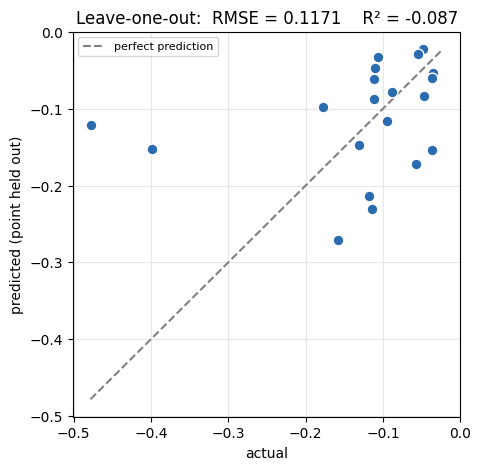

RMSE                       : 0.1171
RMSE if predicting the mean: 0.1123
Ratio                      : 1.042   (below 1 beats guessing)
R²                         : -0.087

Below zero. The model predicts held-out points WORSE than simply
guessing the average would. It is not merely weak — it is actively
misleading, and every suggestion below rests on nothing.


In [6]:
# -----------------------------------------------------------------
#  LEAVE-ONE-OUT VALIDATION
# -----------------------------------------------------------------
predicted = np.empty(len(Y_model))

for train_idx, test_idx in LeaveOneOut().split(X):
    k = (ConstantKernel(1.0, (1e-3, 1e3))
         * Matern(nu=2.5, length_scale=0.3, length_scale_bounds=(0.01, 2.0))
         + WhiteKernel(0.01, (1e-6, 1.0)))
    g = GaussianProcessRegressor(kernel=k, n_restarts_optimizer=3,
                                 normalize_y=True, random_state=42)
    g.fit(X[train_idx], Y_model[train_idx])
    predicted[test_idx] = g.predict(X[test_idx])

residuals = Y_model - predicted
r2 = 1 - (residuals ** 2).sum() / ((Y_model - Y_model.mean()) ** 2).sum()

# RMSE: the average size of the prediction error, in the units of the
# target. Unlike R2 it is an absolute measure, so it says how wrong the
# model is rather than only how it compares with guessing.
rmse = np.sqrt((residuals ** 2).mean())

# RMSE we would get by always predicting the mean - the benchmark any
# useful model has to beat.
baseline = np.sqrt(((Y_model - Y_model.mean()) ** 2).mean())
ratio    = rmse / baseline

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(Y_model, predicted, s=60, c="#2b6cb0", edgecolors="white", zorder=3)
lims = [min(Y_model.min(), predicted.min()), max(Y_model.max(), predicted.max())]
ax.plot(lims, lims, "--", color="grey", label="perfect prediction")
ax.set_xlabel("actual")
ax.set_ylabel("predicted (point held out)")
ax.set_title(f"Leave-one-out:  RMSE = {rmse:.4g}    R² = {r2:.3f}")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

print(f"RMSE                       : {rmse:.4g}")
print(f"RMSE if predicting the mean: {baseline:.4g}")
print(f"Ratio                      : {ratio:.3f}   (below 1 beats guessing)")
print(f"R²                         : {r2:.3f}")
if r2 < 0:
    print("\nBelow zero. The model predicts held-out points WORSE than simply")
    print("guessing the average would. It is not merely weak — it is actively")
    print("misleading, and every suggestion below rests on nothing.")
elif r2 < 0.2:
    print("\nVery low. The model barely improves on predicting the average.")
elif r2 < 0.5:
    print("\nModerate. The model has learned something but is not reliable.")
else:
    print("\nThe model predicts held-out points reasonably well.")

## 5. Prediction grid and Expected Improvement

EI(x) = (μ(x) − Y_best − ξ) · Φ(Z) + σ(x) · φ(Z),  where Z = (μ(x) − Y_best − ξ) / σ(x)

**ξ = 0.05** — balanced. With 20 observations spread over three dimensions the
surface is still being mapped, so neither pure exploitation nor heavy
exploration is appropriate. Raising it to 0.10 would push harder into
unexplored regions.

**EI over UCB** for the same reason as Function 2: the drug response surface
may be multimodal, with different compound ratios producing separate local
optima. EI discounts regions whose mean sits far below the incumbent even when
uncertainty there is high, which keeps the search from being pulled toward
places that are merely unexplored.

The grid is 30³ = 27,000 candidate points.

In [7]:
# -----------------------------------------------------------------
#  3D PREDICTION GRID  (30^3 = 27,000 candidates)
# -----------------------------------------------------------------
n_grid = 30
x_vals = np.linspace(0, 1, n_grid)
g      = np.meshgrid(x_vals, x_vals, x_vals, indexing="ij")
X_grid = np.column_stack([gi.ravel() for gi in g])

post_mean, post_std = model.predict(X_grid, return_std=True)


# -----------------------------------------------------------------
#  EXPECTED IMPROVEMENT
# -----------------------------------------------------------------
Y_best = Y_model.max()


def expected_improvement(mu, sigma, y_best, xi=0.05):
    improvement = mu - y_best - xi

    # Where sigma is effectively zero, Z would divide by zero. Set it to 0.0
    # and zero the resulting EI: a point with no uncertainty offers no
    # possibility of a surprise.
    Z  = np.where(sigma > 1e-9, improvement / sigma, 0.0)
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 1e-9] = 0.0
    return ei


ei_values = expected_improvement(post_mean, post_std, Y_best, xi)


# -----------------------------------------------------------------
#  NEXT SAMPLE
# -----------------------------------------------------------------
best_idx = np.argmax(ei_values)
x_next   = X_grid[best_idx]

print(f"Current best Y        : {Y_best:.6f}")
print(f"  at X                : {X[np.argmax(Y)]}")
print(f"\nNext point to sample  : {np.round(x_next, 6).tolist()}")
print(f"Max EI value          : {ei_values[best_idx]:.6f}")

# How many coordinates sit on the boundary of the search space?
on_bound = np.sum((x_next <= 1e-6) | (x_next >= 0.999))
print(f"Coordinates on the boundary: {on_bound} of 3")

Current best Y        : -0.034835
  at X                : [0.492581 0.611593 0.340176]

Next point to sample  : [0.689655, 1.0, 0.0]
Max EI value          : 0.013206
Coordinates on the boundary: 2 of 3


## 6. Visualisation

Nine panels: three pairwise slices (c1–c2, c1–c3, c2–c3) across three rows
(GP mean, uncertainty, EI). In each panel the third compound is held fixed at
the next sample's value, shown in the panel title.

The middle row is the most diagnostic. EI can only choose sensibly if
uncertainty is low near the observations and high away from them. If
uncertainty looks close to uniform, the model has not learned the surface and
the bottom row is effectively a map of "distance from the nearest data point".

A caveat on reading these: the white dots are **all** observations projected
onto the plane, including ones whose fixed coordinate is far from the slice.
A point can look adjacent to the star while being distant in the third
dimension.

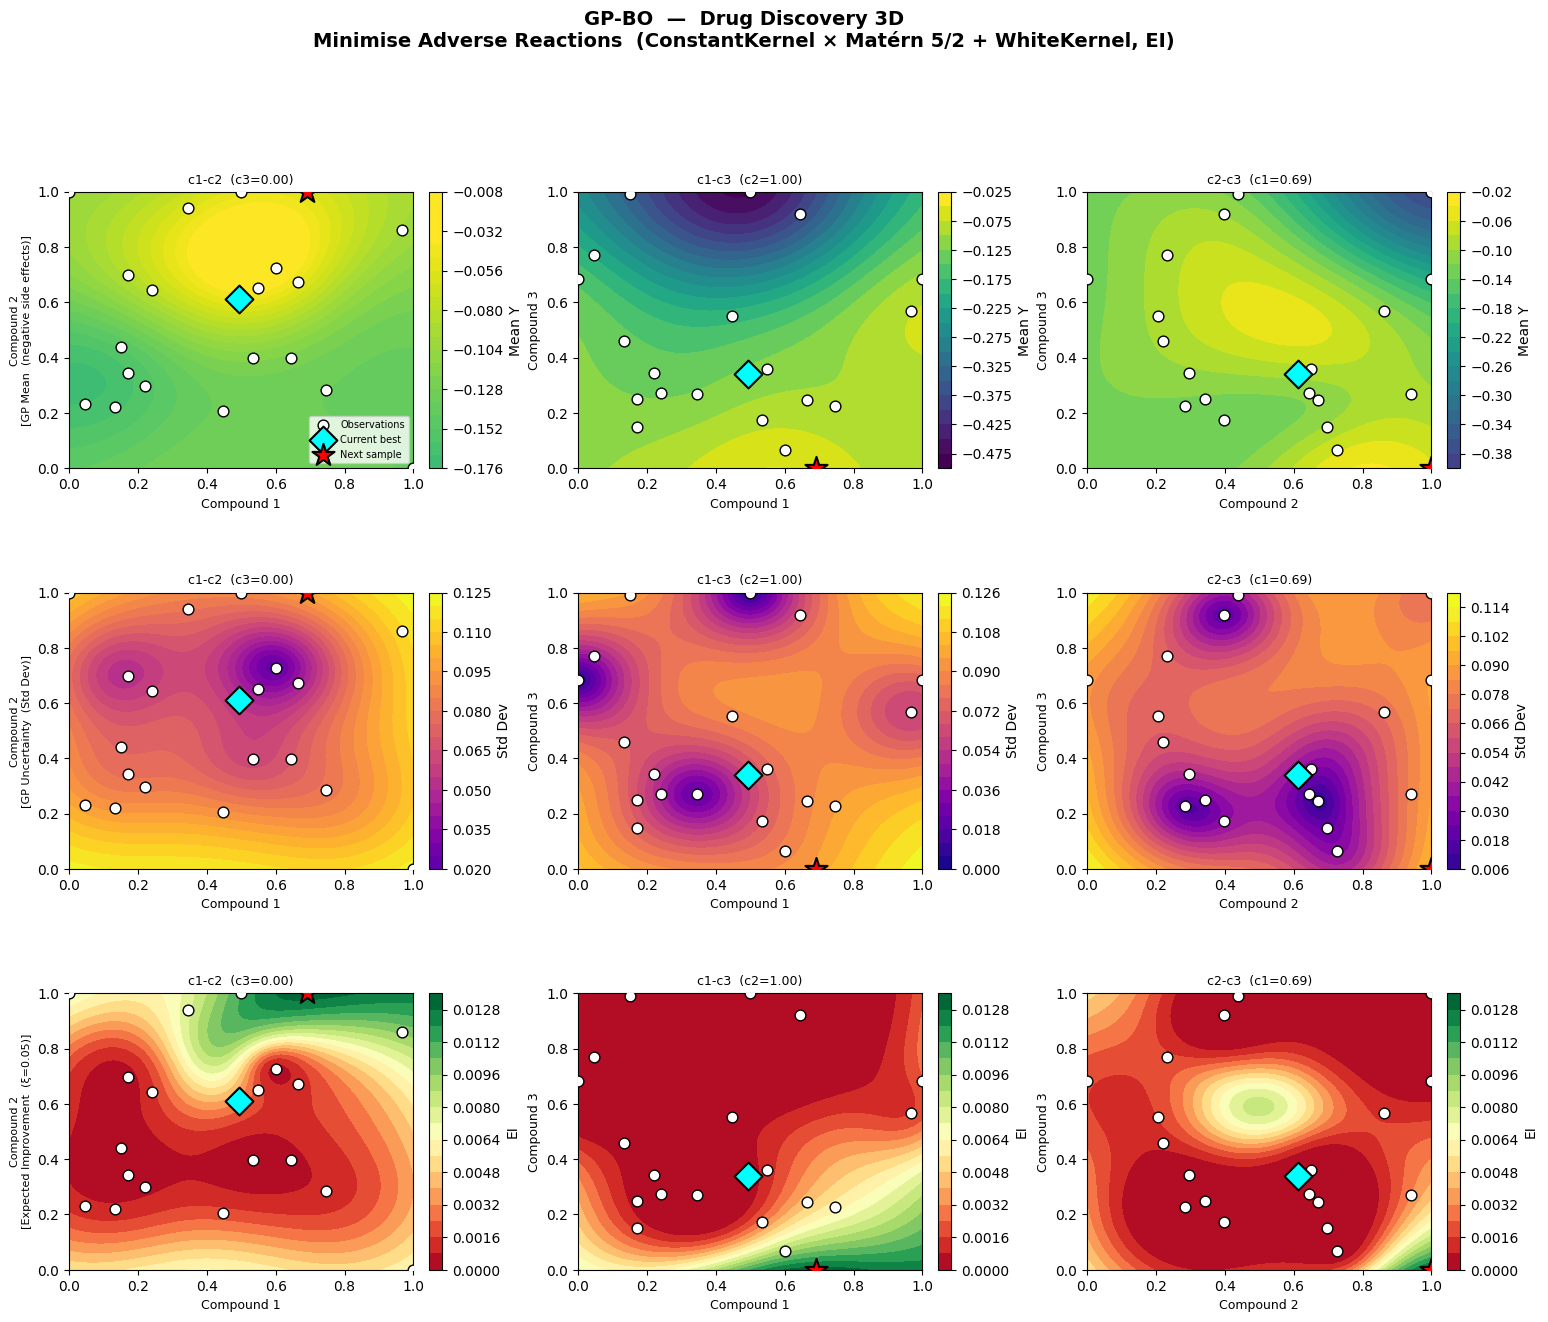

In [8]:
# -----------------------------------------------------------------
#  VISUALISATION — C(3,2) = 3 pairwise slices, 3 rows
# -----------------------------------------------------------------
n_slice     = 100
s_vals      = np.linspace(0, 1, n_slice)
S1, S2      = np.meshgrid(s_vals, s_vals)
axis_names  = ["Compound 1", "Compound 2", "Compound 3"]
short_names = ["c1", "c2", "c3"]
PAIRS       = list(combinations(range(3), 2))      # (0,1), (0,2), (1,2)

ROW_LABELS = [
    "GP Mean  (negative side effects)",
    "GP Uncertainty  (Std Dev)",
    f"Expected Improvement  (\u03be={xi})",
]

fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "GP-BO  —  Drug Discovery 3D\n"
    "Minimise Adverse Reactions  "
    "(ConstantKernel \u00d7 Mat\u00e9rn 5/2 + WhiteKernel, EI)",
    fontsize=14, fontweight="bold", y=1.01,
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

c_best = np.argmax(Y)

for row in range(3):
    for col, (ax_a, ax_b) in enumerate(PAIRS):

        ax = fig.add_subplot(gs[row, col])

        # 2-D slice: vary two compounds, fix the third at x_next's value
        fix_ax = [i for i in range(3) if i not in (ax_a, ax_b)][0]
        grid   = np.tile(x_next, (n_slice ** 2, 1))
        grid[:, ax_a] = S1.ravel()
        grid[:, ax_b] = S2.ravel()

        mu_sl, std_sl = model.predict(grid, return_std=True)
        ei_sl = expected_improvement(mu_sl, std_sl, Y_best, xi)

        if row == 0:
            Z, cmap    = mu_sl.reshape(n_slice, n_slice), "viridis"
            vmin, vmax = Y.min(), Y.max()
            cb_label   = "Mean Y"
        elif row == 1:
            Z, cmap    = std_sl.reshape(n_slice, n_slice), "plasma"
            vmin, vmax = 0, std_sl.max()
            cb_label   = "Std Dev"
        else:
            Z, cmap    = ei_sl.reshape(n_slice, n_slice), "RdYlGn"
            vmin, vmax = 0, max(ei_sl.max(), 1e-9)
            cb_label   = "EI"

        cf = ax.contourf(S1, S2, Z, levels=20, cmap=cmap, vmin=vmin, vmax=vmax)

        # All observations projected onto this plane
        ax.scatter(X[:, ax_a], X[:, ax_b], c="white", s=60,
                   edgecolors="black", linewidths=1.0, zorder=10,
                   label="Observations")

        # Current best
        ax.scatter(X[c_best, ax_a], X[c_best, ax_b], c="cyan", s=200,
                   marker="D", edgecolors="black", linewidths=1.5,
                   zorder=11, label="Current best")

        # Next sample
        ax.scatter(x_next[ax_a], x_next[ax_b], c="red", s=280,
                   marker="*", edgecolors="black", linewidths=1.5,
                   zorder=12, label="Next sample")

        fix_label = f"{short_names[fix_ax]}={x_next[fix_ax]:.2f}"
        ax.set_xlabel(axis_names[ax_a], fontsize=9)
        ax.set_title(f"{short_names[ax_a]}-{short_names[ax_b]}  ({fix_label})",
                     fontsize=9)

        if col == 0:
            ax.set_ylabel(f"{axis_names[ax_b]}\n[{ROW_LABELS[row]}]", fontsize=8)
        else:
            ax.set_ylabel(axis_names[ax_b], fontsize=9)

        plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.04, label=cb_label)

        if row == 0 and col == 0:
            ax.legend(fontsize=7, loc="lower right")

plt.show()

## 7. Round-by-round review

No improvement in five rounds. The best value is still the −0.0348 supplied in
the starting data.

**The R² above is the worst of all eight functions — below zero.** That means
the model predicts a held-out point *worse* than simply guessing the average
would. It is not a weak model; it is an actively misleading one, and every
query it recommended rested on nothing.

The query pattern follows directly:

| Round | Query | Result | Interior or boundary |
|---|---|---|---|
| 1 | [0.550, 0.650, 0.360] | −0.0372 | interior |
| 2 | [0.500, 1.000, 1.000] | −0.4782 | boundary ×2 |
| 3 | [1.000, 0.000, 0.684] | −0.1769 | boundary ×2 |
| 4 | [0.000, 1.000, 0.684] | −0.1581 | boundary ×2 |
| 5 | [0.448, 0.207, 0.552] | −0.0541 | interior |

The two interior queries returned −0.037 and −0.054 — close to the incumbent.
The three boundary queries returned −0.48, −0.18 and −0.16, between three and
fourteen times worse.

This is the corner-sampling pattern seen on Functions 1 and 4, and the cause is
the same. With a model that cannot distinguish one region from another,
predicted uncertainty is near-uniform away from the data, and EI degenerates
into selecting whichever grid point is furthest from an existing observation.
On a uniform 30³ grid, that is always at the edge.

**What would help.** Twenty points across three dimensions is thin, and the
first priority is coverage rather than optimisation. Three concrete changes:

1. **Generate candidates from a Sobol sequence rather than a grid.** A grid
   places its furthest-from-data points at the boundary by construction.
2. **Constrain queries to the interior** while R² remains negative — the two
   interior samples substantially outperformed the three boundary ones.
3. **Re-check after each round.** Once R² rises above roughly 0.3, the model's
   recommendations become worth following; below that, coverage is the better
   use of a query.

In [9]:
# -----------------------------------------------------------------
#  ROUND-BY-ROUND LOG
# -----------------------------------------------------------------
rows = []
for r in range(1, week.max() + 1):
    i = np.where(week == r)[0][0]
    n_bound = int(np.sum((X[i] <= 1e-6) | (X[i] >= 0.999)))
    rows.append({
        "round":      r,
        "submitted":  "[" + ", ".join(f"{v:.3f}" for v in X[i]) + "]",
        "Y":          round(float(Y[i]), 6),
        "best after": round(float(Y[week <= r].max()), 6),
        "improved":   "yes" if Y[i] > Y[week < r].max() else "no",
        "on boundary": f"{n_bound} of 3" if n_bound else "no",
    })

pd.DataFrame(rows)

,round,submitted,Y,best after,improved,on boundary
0,1,"[0.550, 0.650, 0.360]",-0.037156,-0.034835,no,no
1,2,"[0.500, 1.000, 1.000]",-0.478170,-0.034835,no,2 of 3
2,3,"[1.000, 0.000, 0.684]",-0.176918,-0.034835,no,2 of 3
3,4,"[0.000, 1.000, 0.684]",-0.158070,-0.034835,no,2 of 3
4,5,"[0.448, 0.207, 0.552]",-0.054088,-0.034835,no,no


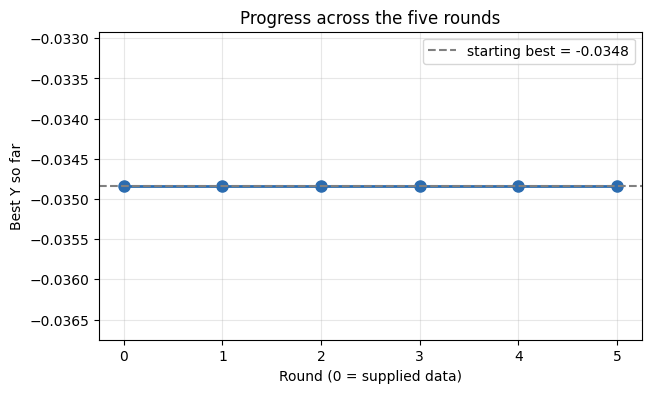

In [10]:
# Best value so far, after each round. A flat line means a whole round
# passed without improving on what was already known.

rounds      = np.arange(week.max() + 1)
best_so_far = [Y[week <= r].max() for r in rounds]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rounds, best_so_far, "o-", linewidth=2, markersize=8, color="#2b6cb0")
ax.axhline(best_so_far[0], color="grey", linestyle="--",
           label=f"starting best = {best_so_far[0]:.4f}")
ax.set_xlabel("Round (0 = supplied data)")
ax.set_ylabel("Best Y so far")
ax.set_title("Progress across the five rounds")
ax.set_xticks(rounds)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [11]:
# -----------------------------------------------------------------
#  SUMMARY
# -----------------------------------------------------------------
best_obs_idx = np.argmax(Y)

print("=" * 60)
print("Summary — Drug Discovery 3D")
print("=" * 60)
print(f"  Total observations        : {len(X)}")
print(f"  Best Y so far             : {Y[best_obs_idx]:.6f}")
print(f"  (least adverse reactions) : {X[best_obs_idx]}")
print(f"  Found in round            : {week[best_obs_idx]}")
print(f"  Transform                 : none")
print(f"  Kernel                    : ConstantKernel x Matern(nu=2.5) + WhiteKernel")
print(f"  Fitted length_scale       : {fitted_ls:.4g}")
print(f"  Model quality (R2)        : {r2:.3f}")
print(f"  EI xi parameter           : {xi}  (balanced)")
print(f"  Next point to sample      : {np.round(x_next, 6).tolist()}")
print(f"  Max EI value              : {ei_values[best_idx]:.6f}")
print("=" * 60)

Summary — Drug Discovery 3D
  Total observations        : 20
  Best Y so far             : -0.034835
  (least adverse reactions) : [0.492581 0.611593 0.340176]
  Found in round            : 0
  Transform                 : none
  Kernel                    : ConstantKernel x Matern(nu=2.5) + WhiteKernel
  Fitted length_scale       : 0.3671
  Model quality (R2)        : -0.087
  EI xi parameter           : 0.05  (balanced)
  Next point to sample      : [0.689655, 1.0, 0.0]
  Max EI value              : 0.013206


---

See `MODEL_CARD.md` for how this function compares with the other seven and for
the full list of assumptions and limitations, and `DATASHEET.md` for known gaps
and biases in the data.